# 0.0 Установка # Обновление пакета geomml 

In [ ]:
from pathlib import Path
import os

root = Path(os.getcwd()).resolve().parents[1]  # вверх на 2 уровня
!python {str(root / "scripts" / "bootstrap.py")}

%load_ext autoreload
%autoreload 2

from hydra import initialize_config_dir, compose
from hydra.utils import instantiate

config_name = "default"

with initialize_config_dir(config_dir=str(root / "configs"), version_base="1.3"):
    cfg = compose(config_name=config_name)

# При начальной установке и запуске может не сработать, нужно перезапустить cell. Бага в разработке, пока не исправлена. 


# 0.1 Импорт необходимых модулей # библиотек

In [8]:
#!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.1.0+cu121.html
#!pip install torch-sparse  -f https://data.pyg.org/whl/torch-2.1.0+cu121.html
#!pip install torch-cluster -f https://data.pyg.org/whl/torch-2.1.0+cu121.html
#!pip install torch-geometric

import torch.nn.functional as F
from torch_geometric.loader import DataLoader

from geomml.models import build as build_model
from geomml.datasets import build as build_dataset
from geomml.losses.kendall import * 
from geomml.utils.loader import build as build_loaders
from geomml.utils.plot_history import *
from geomml.trainers.multi_task import MultiTaskTrainer
from geomml.trainers.evaluate_model import print_metrics

%matplotlib inline
N_EPOCHS=1000

# 0.2 Скачивание датасета Alchemy

In [3]:
import geomml.datasets.alchemy
import pandas as pd

# !python {str(root / "scripts" / "download_alchemy.py")}

DATA_DIR = Path("data") / "alchemy"
targets = pd.read_csv(DATA_DIR / "final_version.csv")
print(list(targets.columns))
print(targets.head())
print(targets.columns)

['gdb_idx', 'atom number', 'zpve\n(Ha, zero point vibrational energy)', 'Cv\n(cal/molK, heat capacity at 298.15 K)', 'gap\n(Ha, LUMO-HOMO)', 'G\n(Ha, Free energy at 298.15 K)', 'HOMO\n(Ha, energy of HOMO)', 'U\n(Ha, internal energy at 298.15 K)', 'alpha\n(a_0^3, Isotropic polarizability)', 'U0\n(Ha, internal energy at 0 K)', 'H\n(Ha, enthalpy at 298.15 K)', 'LUMO\n(Ha, energy of LUMO)', 'mu\n(D, dipole moment)', 'R2\n(a_0^2, electronic spatial extent)']
   gdb_idx  atom number  zpve\n(Ha, zero point vibrational energy)  \
0  2859833            9                                   0.226164   
1  3148292            9                                   0.180782   
2  3607838            9                                   0.205922   
3  9540153           11                                   0.160845   
4   340363           10                                   0.177712   

   Cv\n(cal/molK, heat capacity at 298.15 K)  gap\n(Ha, LUMO-HOMO)  \
0                                   0.000067       

# 0.3 Подготовка **QM9+Alchemy** multi-dataset

In [10]:
#!python {str(root / "scripts" / "preprocess_alchemy.py")}

alchemy = build_dataset("alchemy", normalize=True)
qm9 = build_dataset("qm9",normalize=True)
dataset = build_dataset("unified", datasets=[qm9, alchemy], normalize=False)

print("Alchemy:\t",     alchemy[0])
print("QM9:\t\t",       qm9[0])
print("Full Dataset:\t",dataset[0])


Alchemy:	 Data(pos=[21, 3], z=[21], y=[1, 1], task_id=0, charge=[21], aromatic=[21], edge_index=[2, 52], edge_attr=[52])
QM9:		 Data(edge_index=[2, 20], pos=[5, 3], z=[5], y=[1, 1], task_id=0, charge=[5], aromatic=[5], edge_attr=[20])
Full Dataset:	 Data(z=[5], pos=[5, 3], edge_index=[2, 20], edge_attr=[20], aromatic=[5], charge=[5], y=[1, 1], mask_y=[1, 1], task_id=0)


# 0.4 Проверка target statistics # dataset diagnostic


In [5]:
from geomml.utils.diagnostics import *

inspect_dataset(dataset)

loaders = build_loaders( # Разделение train/val/test # Подготовка DataLoader'ов
    dataset,
    batch_size=32,
    train_size=0.8,
    valid_size=0.1,
)

inspect_loader(loaders.train)

del loaders


=== Different schemas ===
333410 ('aromatic', 'charge', 'edge_attr', 'edge_index', 'mask_y', 'pos', 'task_id', 'y', 'z')

=== Target statistics ===
task 0: mean=6.8585 std=1.2842 min=0.6694 max=16.9282
task 1: mean=0.2349 std=0.0553 min=0.0362 max=0.4066

Dataset size: 333410


=== Loader statistics ===
y mean=2.8341 std=3.3329 min=0.0362 max=16.9282
pos mean=0.1110 std=3.1664 min=-178.6185 max=176.2455


# 1.0 Постановка задачи

Улучшение предсказаний вектора дипольного момента (и тензора поляризуемости) молекул датасета Alchemy с использованием GeomML + TDA

# 2.0 DimeNET-Lite


Текущая модель ближе к RBF-MPNN + distance message passing.  Она не использует углы:
* нет triplet interaction;
* нет spherical basis;
* нет angular embedding.

Классический `DimeNet` использует угловые взаимодействия `j−i−k`, а рассматриваемый `DimeNetLite` — упрощённый радиальный вариант  — использует радиальные базисные функции (RBF) и граф по радиусу, но не включает угловые взаимодействия (triplets), сферические базисы и полный блок взаимодействий из оригинального DimeNet. 

За счёт этого модель значительно компактнее и проще в обучении.

Поэтому на представленной блок-схеме данной модели присутствует название "DimeNet-Lite / RBF Message Passing Network".


```mermaid
flowchart TB

%% =====================================================
%% Molecular Geometry Branch
%% =====================================================
subgraph Geometry_Branch["Geometry Branch : DimeNet-Lite / RBF-MPNN"]

A[Atomic Features<br/>Z Atomic Numbers<br/>z ∈ ℕ]

B[Atom Embedding<br/>Embedding Layer<br/>h0 ∈ ℝ²⁵⁶]

C[Graph Topology<br/>edge_index from Batch<br/>or Radius Graph]

D[Distance Calculation<br/>d_ij = #124;#124; r_i -r_j #124;#124;]

E[RBF Expansion<br/>Distance → Radial Basis Features<br/>eij ∈ ℝ³²]

F[DimeNet-Lite Message Passing × L<br/>Edge Message:<br/>h_i, h_j, RBF#40;dij&#41<br/>Node Aggregation + <br/> + Residual Update]

G[Graph Representation<br/>Global Mean Pooling<br/>h_geom ∈ ℝ²⁵⁶]

A --> B
C --> D
D --> E
B --> F
E --> F
F --> G

end


%% =====================================================
%% Optional TDA Branch
%% =====================================================
subgraph TDA_Branch["Optional Topology Branch"]

H[TDA Features<br/>tda ∈ ℝⁿ]

I[TDA Encoder<br/>MLP + SiLU]

J[Topology Embedding<br/>h_tda ∈  ℝ²⁵⁶]

I --> J --> K

end


%% =====================================================
%% Task Conditioning
%% =====================================================
subgraph Task_Branch["Task Conditioning"]

K[Task ID<br/>Dataset / Type]

L[Task Embedding<br/>Embedding Layer<br/>h_task ∈ ℝ²⁵⁶]

K --> L

end


%% =====================================================
%% Fusion
%% =====================================================

G --> M[Feature Concatenation<br/>h_geom + h_tda + h_task]

J --> M
L --> M

M --> N[Fusion MLP<br/>Linear + SiLU + LayerNorm]

N --> O[Shared Backbone<br/>MLP Encoder]

P[Single Regression Head<br/>Linear + SiLU + Linear]

O --> P

%% =====================================================
%% Output
%% =====================================================
subgraph Outputs["Regression Output"]

Q[Prediction<br/>y ∈ ℝ]

end
P --> Q


```

Сама модель представлена в папке проекта `/src/geomml/models/` , см. файл `dimenet_lite.py`.

Контракт/Интерфейс для архитектуры модели будет:
```python
batch format
Data(
    z,
    pos,
    edge_index,
    batch,
    task_id,   # (!)
    y,         # QM9
    mu,        # опционально
    alpha      # опционально
)
```

## 2.1 Обучение на Alchemy dataset

Здесь и далее в экспериментах будут применяться параметры для optimizer и scheduler из default-конфигов в директории `configs`. Конкретно, это:
```python
optimizer = AdamW (
      lr: 3e-4
      weight_decay: 1e-5
)
```
и
```python
scheduler = ReduceLROnPlateau (
    mode: min       # минимизируем val_mse
    factor: 0.5     # уменьшить LR в 2 раза
    patience: 3     # если 3 эпохи нет улучшения
    min_lr: 1e-6
)
```



Dataset size: 202579

Epoch [   1/1000] | TrainLoss: 0.003562 | ValidLoss: 0.003084 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 120.17s | 
Epoch [   2/1000] | TrainLoss: 0.003117 | ValidLoss: 0.003059 | LR: 3.00e-04 | EarlyStop: 1 /20 | EpochTime: 121.19s | 
Epoch [   3/1000] | TrainLoss: 0.003096 | ValidLoss: 0.003081 | LR: 3.00e-04 | EarlyStop: 2 /20 | EpochTime: 117.22s | 
Epoch [   4/1000] | TrainLoss: 0.003092 | ValidLoss: 0.003205 | LR: 3.00e-04 | EarlyStop: 3 /20 | EpochTime: 111.90s | 
Epoch [   5/1000] | TrainLoss: 0.003101 | ValidLoss: 0.003078 | LR: 3.00e-04 | EarlyStop: 4 /20 | EpochTime: 118.01s | 
Epoch [   6/1000] | TrainLoss: 0.003092 | ValidLoss: 0.003086 | LR: 1.50e-04 | EarlyStop: 5 /20 | EpochTime: 113.10s | 
Epoch [   7/1000] | TrainLoss: 0.003077 | ValidLoss: 0.003071 | LR: 1.50e-04 | EarlyStop: 6 /20 | EpochTime: 112.79s | 
Epoch [   8/1000] | TrainLoss: 0.003077 | ValidLoss: 0.003083 | LR: 1.50e-04 | EarlyStop: 7 /20 | EpochTime: 115.40s | 
Epoch [   9/1000]

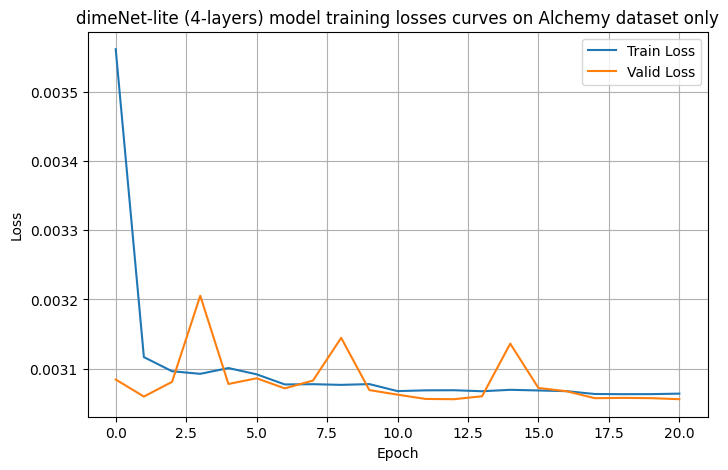


Overall:
mse  : 0.003103
rmse : 0.055708
mae  : 0.045458

Per task:
Task  0 | MSE=0.003103	RMSE=0.055708	MAE=0.045458	


In [11]:
loaders = build_loaders( # Разделение train/val/test # Подготовка DataLoader'ов
    alchemy,
    batch_size=32,
    train_size=0.8,
    valid_size=0.1,
)

model = build_model("dimenet_lite", hidden_dim=256, layers=4)
optimizer = instantiate(cfg.optimizer, params=model.parameters())
scheduler = instantiate(cfg.scheduler, optimizer)

trainer = MultiTaskTrainer(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    # criterion = default_model.loss_fn,
    patience=20,
    min_delta=1e-4,
#    checkpoint_name="best_dimenet-lite_alchemy",
)

model, history = trainer.fit(
    train_loader=loaders.train,
    valid_loader=loaders.valid,
    num_epochs=N_EPOCHS
)

plot_history(history, title="dimeNet-lite (4-layers) model training losses curves on Alchemy dataset only")
print_metrics(model, loaders.test)

del optimizer, model, trainer, history, loaders, scheduler

### Hаблюдения
1. Обучение выглядит довольно здоровым:
* корректный regression loss и нет ухода Loss в отрицательные значения
* Train ≈ Valid. Разница минимальная: ∣0.00306−0.00308∣≈2×$10^{−5}$

Это говорит, что:
* нет явного переобучения;
* модель не запоминает train;
* регуляризация работает.

2. Похоже на раннее плато
```python
Epoch  1 0.003562 
Epoch  4 0.003092
Epoch 12 0.003068 
Epoch 20 0.003063 
```
То есть модель почти сразу вышла на минимум. 

```mermaid
flowchart TB

subgraph Сейчас архитектура:
A[DimeNetLite]
    
B[4 × DimeLayer]
    
C[mean pooling]

A --> B --> C
end
``` 
Но, как отмечалось выше, нет:
* угловых взаимодействий;
* residual normalization;
* attention pooling;
* edge features

(Это скорее SchNet-lite).

3. Похоже, есть недообучение (underfitting) - Train loss почти равен Validation.

Если бы модель могла лучше описывать данные, было бы что-то вроде:
```python
Train = 0.0015
Valid = 0.0023
```
или
```python
Train = 0.0020
Valid = 0.0025
```
Здесь же `Train ≈ Valid`, скорее всего, означает, модель не способна сильнее уменьшить ошибку даже на обучающей выборке.
Это классический underfitting.

3. Возможно, архитектура недостаточно "выразительная". Попробуем добавать больше глубины в сеть:
```python
 DimeEncoder(hidden_dim=256, layers=4) ---> DimeEncoder(hidden_dim=256, layers=6)
```


Dataset size: 202579

Epoch [   1/1000] | TrainLoss: 0.003493 | ValidLoss: 0.003364 | LR: 3.00e-04 | EarlyStop: 0 /30 | EpochTime: 204.43s | 
Epoch [   2/1000] | TrainLoss: 0.003134 | ValidLoss: 0.003032 | LR: 3.00e-04 | EarlyStop: 0 /30 | EpochTime: 205.18s | 
Epoch [   3/1000] | TrainLoss: 0.003111 | ValidLoss: 0.003064 | LR: 3.00e-04 | EarlyStop: 1 /30 | EpochTime: 203.64s | 
Epoch [   4/1000] | TrainLoss: 0.003101 | ValidLoss: 0.003061 | LR: 3.00e-04 | EarlyStop: 2 /30 | EpochTime: 205.00s | 
Epoch [   5/1000] | TrainLoss: 0.003094 | ValidLoss: 0.003028 | LR: 3.00e-04 | EarlyStop: 3 /30 | EpochTime: 205.26s | 
Epoch [   6/1000] | TrainLoss: 0.003091 | ValidLoss: 0.003056 | LR: 3.00e-04 | EarlyStop: 4 /30 | EpochTime: 206.18s | 
Epoch [   7/1000] | TrainLoss: 0.003087 | ValidLoss: 0.003050 | LR: 3.00e-04 | EarlyStop: 5 /30 | EpochTime: 203.94s | 
Epoch [   8/1000] | TrainLoss: 0.003083 | ValidLoss: 0.003030 | LR: 3.00e-04 | EarlyStop: 6 /30 | EpochTime: 204.29s | 
Epoch [   9/1000]

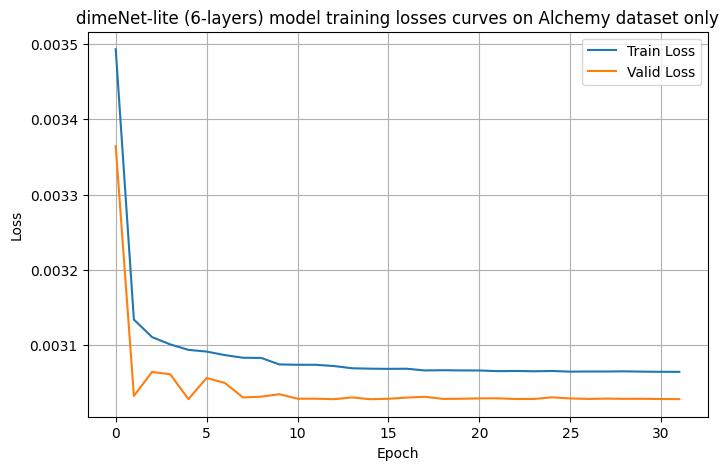


Overall:
mse  : 0.003059
rmse : 0.055308
mae  : 0.045008

Per task:
Task  0 | MSE=0.003059	RMSE=0.055308	MAE=0.045008	


In [7]:
loaders = build_loaders( # Разделение train/val/test # Подготовка DataLoader'ов
    alchemy,
    batch_size=32,
    train_size=0.8,
    valid_size=0.1,
)

model = build_model("dimenet_lite", hidden_dim=256, layers=6)
optimizer = instantiate(cfg.optimizer, params=model.parameters())
scheduler = instantiate(cfg.scheduler, optimizer)

trainer = MultiTaskTrainer(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    # criterion = default_model.loss_fn,
    patience=30,
    min_delta=1e-4,
#    checkpoint_name="best_dimenet-lite_alchemy",
)

model, history = trainer.fit(
    train_loader=loaders.train,
    valid_loader=loaders.valid,
    num_epochs=N_EPOCHS
)

plot_history(history, title="dimeNet-lite (6-layers) model training losses curves on Alchemy dataset only")
print_metrics(model, loaders.test)

del optimizer, model, trainer, history, loaders, scheduler


### Hаблюдения

Модель снова практически сразу упёрлась в плато - увеличение глубины с 4 до 6 слоёв почти не дало прироста.
То есть выигрыш практически нулевой: $Δ≈10^{−6}$.

При этом:

* время эпохи: ~115s → ~200s (в 1.8 раза)
* параметров стало больше
* глубина стала больше
а выигрыш оказался примерно $\frac{0.003056−0.003028}{0.003056}​ ≈ 0.9\%$ (менее 1%).

Если оценить эффективность:
* вычислительная стоимость: +80%;
* выигрыш по validation: около 1%.

Это довольно низкая отдача от увеличения глубины.

То есть увеличение layers не является сейчас узким местом.

Дальше scheduler сделал: $3.0e^{-4}$ -> $1.5e^{-4}$ -> $7.5e^{-5}$ -> $1.87e^{-5}$, но улучшения нет.

Это означает, что оптимизатор и глубина - не проблема.

Скорее всего, ограничение в представлении данных. Попробуем обогатить Alchemy информацией, добавив к нему QM9.

## 2.2 Обучение на Alchemy + QM9 multi-dataset


Dataset size: 333410

Epoch [   1/1000] | TrainLoss: 0.117167 | ValidLoss: 0.061711 | LR: 3.00e-04 | EarlyStop: 0 /15 | EpochTime: 206.91s | Best Model State was Saved
Epoch [   2/1000] | TrainLoss: 0.050743 | ValidLoss: 0.038907 | LR: 3.00e-04 | EarlyStop: 0 /15 | EpochTime: 226.30s | Best Model State was Saved
Epoch [   3/1000] | TrainLoss: 0.040663 | ValidLoss: 0.032956 | LR: 3.00e-04 | EarlyStop: 0 /15 | EpochTime: 197.56s | Best Model State was Saved
Epoch [   4/1000] | TrainLoss: 0.035555 | ValidLoss: 0.043950 | LR: 3.00e-04 | EarlyStop: 1 /15 | EpochTime: 204.22s | 
Epoch [   5/1000] | TrainLoss: 0.031145 | ValidLoss: 0.027099 | LR: 3.00e-04 | EarlyStop: 0 /15 | EpochTime: 237.97s | Best Model State was Saved
Epoch [   6/1000] | TrainLoss: 0.028876 | ValidLoss: 0.026265 | LR: 3.00e-04 | EarlyStop: 0 /15 | EpochTime: 320.63s | Best Model State was Saved
Epoch [   7/1000] | TrainLoss: 0.026958 | ValidLoss: 0.027481 | LR: 3.00e-04 | EarlyStop: 1 /15 | EpochTime: 319.43s | 
Epoch [

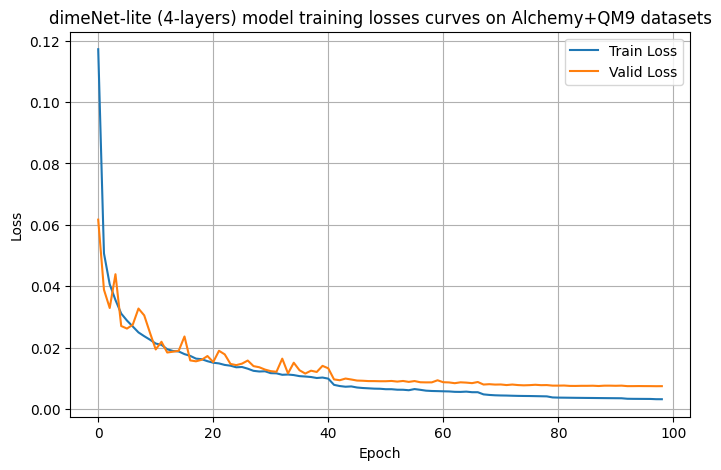


Overall:
mse  : 0.008012
rmse : 0.089507
mae  : 0.060435

Per task:
Task  0 | MSE=0.015595	RMSE=0.124880	MAE=0.083978	
Task  1 | MSE=0.003106	RMSE=0.055731	MAE=0.045206	


In [8]:
loaders = build_loaders( # Разделение train/val/test # Подготовка DataLoader'ов
    dataset, 
    batch_size=32,
    train_size=0.8,
    valid_size=0.1,
)

model = build_model("dimenet_lite", hidden_dim=256, layers=4)
optimizer = instantiate(cfg.optimizer, params=model.parameters())
scheduler = instantiate(cfg.scheduler, optimizer)

trainer = MultiTaskTrainer(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    # criterion = default_model.loss_fn,
    patience=15,
    min_delta=1e-4,
    checkpoint_name="best-[dimenet_lite-4-layers]-[mse_loss]-[alchemy+qm9]",
)

model, history = trainer.fit(
    train_loader=loaders.train,
    valid_loader=loaders.valid,
    num_epochs=N_EPOCHS
)

plot_history(history, title="dimeNet-lite (4-layers) model training losses curves on Alchemy+QM9 datasets")
print_metrics(model, loaders.test)

del optimizer, model, trainer, history, loaders, scheduler


Dataset size: 333410

Epoch [   1/1000] | TrainLoss: 0.132524 | ValidLoss: 0.071861 | LR: 3.00e-04 | EarlyStop: 0 /15 | EpochTime: 218.40s | Best Model State was Saved
Epoch [   2/1000] | TrainLoss: 0.055833 | ValidLoss: 0.042568 | LR: 3.00e-04 | EarlyStop: 0 /15 | EpochTime: 218.35s | Best Model State was Saved
Epoch [   3/1000] | TrainLoss: 0.046242 | ValidLoss: 0.044663 | LR: 3.00e-04 | EarlyStop: 1 /15 | EpochTime: 224.36s | 
Epoch [   4/1000] | TrainLoss: 0.053248 | ValidLoss: 0.031885 | LR: 3.00e-04 | EarlyStop: 0 /15 | EpochTime: 225.90s | Best Model State was Saved
Epoch [   5/1000] | TrainLoss: 0.035985 | ValidLoss: 0.036500 | LR: 3.00e-04 | EarlyStop: 1 /15 | EpochTime: 224.59s | 
Epoch [   6/1000] | TrainLoss: 0.032227 | ValidLoss: 0.031519 | LR: 3.00e-04 | EarlyStop: 0 /15 | EpochTime: 271.02s | Best Model State was Saved
Epoch [   7/1000] | TrainLoss: 0.029056 | ValidLoss: 0.031219 | LR: 3.00e-04 | EarlyStop: 0 /15 | EpochTime: 394.36s | Best Model State was Saved
Epoch [

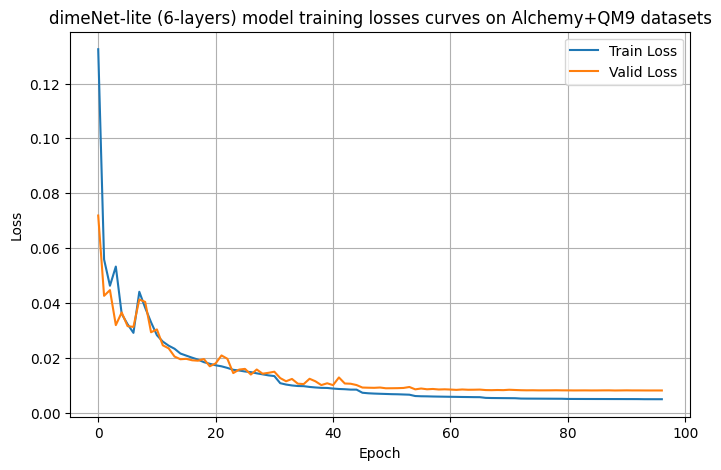


Overall:
mse  : 0.008473
rmse : 0.092051
mae  : 0.063338

Per task:
Task  0 | MSE=0.016802	RMSE=0.129624	MAE=0.091495	
Task  1 | MSE=0.003091	RMSE=0.055597	MAE=0.045143	


In [9]:
loaders = build_loaders( # Разделение train/val/test # Подготовка DataLoader'ов
    dataset, 
    batch_size=32,
    train_size=0.8,
    valid_size=0.1,
)

model = build_model("dimenet_lite", hidden_dim=256, layers=6)
optimizer = instantiate(cfg.optimizer, params=model.parameters())
scheduler = instantiate(cfg.scheduler, optimizer)

trainer = MultiTaskTrainer(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    # criterion = default_model.loss_fn,
    patience=15,
    min_delta=1e-4,
    checkpoint_name="best-[dimenet_lite-6-layers]-[mse_loss]-[alchemy+qm9]",
)

model, history = trainer.fit(
    train_loader=loaders.train,
    valid_loader=loaders.valid,
    num_epochs=N_EPOCHS
)

plot_history(history, title="dimeNet-lite (6-layers) model training losses curves on Alchemy+QM9 datasets")
print_metrics(model, loaders.test)

del optimizer, model, trainer, history, loaders, scheduler

### Hаблюдения

Это уже совсем другая картина. Здесь поведение намного более похоже на нормальное обучение, в отличие от чистого Alchemy, где модель за 3–5 эпох сразу упиралась в плато.

В целом, по сравнению с обучением только на Alchemy, смесь Alchemy + QM9 даёт более содержательную динамику обучения: модель продолжает находить лучшие решения после первых нескольких эпох, а не выходит почти сразу на плато.

Это хороший признак того, что текущая архитектура и настройки оптимизации способны извлекать дополнительную информацию из объединённого набора данных.

### Сводная таблица
| Метрика              |       4 слоя |      6 слоев |
| -------------------- | -----------: | -----------: |
| Лучший Valid Loss    |  **0.00751** |      0.00804 |
| Test Overall MSE     | **0.008012** |     0.008473 |
| Test Overall MAE     |   **0.0604** |       0.0633 |
| Task 0 MSE (QM9)     |   **0.0156** |       0.0168 |
| Task 1 MSE (Alchemy) |     0.003106 | **0.003091** |


1. Похоже, что для этой задачи 4 слоя уже достаточно. Переход к 6 слоям почти вдвое увеличивает время одной эпохи, однако не приводит к улучшению качества на валидационной и тестовой выборках.

Добавление еще двух слоев лишь увеличивает время обучения, уменьшает train loss и почти не улучшает validation/test.

Это соответствует ситуации насыщения модели, когда увеличение её глубины уже не приводит к заметному улучшению качества. 

Более того, есть риск, что 6-слойная модель может начать переобучаться сильнее.



2. Текущий "DimeNet-lite" фактически: `atom embedding --- radius graph --- RBF(distance) --- message passing --- global_mean_pool`

Главное ограничение - отсутствие настоящего DimeNet angular block.

Оригинальный DimeNet использует:
* triplets k-j-i
* углы θ
* spherical Bessel basis
* spherical harmonics
* directional message passing

В текущей реализации есть только расстояния $m_{ij}​ = f(h_i​, h_j​, RBF(r_{ij}​))$

Добавление слоев увеличивает receptive field, число повторных агрегирований, смешивание соседей, но не добавляет новой геометрии.

Поэтому после 4 слоев модель уже видит необходимый радиус информации, а дополнительные слои начинают смешивать шум.


Также есть подозрительный момент в обоих случаях: рост порядка ×10. Это может быть нормально, но нужно проверить масштаб целей. Очень вероятная причина - QM9 и Alchemy имеют разные шкалы.

Для этого воспользуемся пунктом `0.4 Проверка target statistics`, который покажет среднее и стандартное отклонение каждой целевой величины, диапазон значений, нет ли ситуации, когда одна задача имеет значения порядка 0.01, а другая — 100.

Если масштабы сильно различаются, одна задача может доминировать в общей MSE.
```
task 0
N    = 130831
mean = 6.86
std  = 1.28
range = [0.67 ; 16.93]

task 1
N    = 202579
mean = 0.235
std  = 0.055
range = [0.036 ; 0.407]
```
То есть масштабы отличаются очень сильно. Если сравнить стандартные отклонения: $0.055/1.28≈23$, а диапазоны отличаются примерно в 40 раз.

Для MSE это означает, что при подсчете `loss = mse(pred, y)` ошибка по `task 0` в абсолютных единицах будет значительно больше, чем по `task 1`.


3. Если сравнивать качество именно на Alchemy, то результаты ухудшились:

| Метрика | Только Alchemy | Alchemy + QM9 (Task 1) |   Изменение |
| ------- | -------------: | ---------------------: | ----------: |
| MSE     |   **0.003058** |           **0.003091** | ↑ **≈1.1%** |
| RMSE    |   **0.055301** |           **0.055597** | ↑ **≈0.5%** |
| MAE     |   **0.044812** |           **0.045143** | ↑ **≈0.7%** |

При этом модель успешно обучилась решать и задачу QM9, достигая устойчивой сходимости как на обучающей, так и на валидационной выборках. 

Полученные результаты показывают, что архитектура способна эффективно обучаться сразу на двух наборах данных, сохраняя высокое качество на каждой из задач.

Хотя обучение выглядит довольно здоровым на фоне `task_emb` - модель знает, какую задачу решает - но loss пока не знает, что задачи имеют разные масштабы. 

Что следующим хотелось бы попробовать:
1. **Kendall loss**! Вот здесь уже становится действительно интересно - поскольку задачи отличаются по масштабу почти в 23 раза, автоматическое обучение весов задач может дать выигрыш.

2. Нормализация target отдельно для каждой задачи (task_id) — позволит привести обе задачи к сопоставимому масштабу и сделать вклад каждой задачи в общую функцию потерь более сбалансированным.

3. Сравнение с фиксированными весами задач (weighted MSE) — позволит оценить, насколько чувствительно качество к выбору весов без использования автоматически обучаемых коэффициентов.




# 3.0 Kendall loss

### Формула Kendall loss для regression задач:
$$
L = \frac{1}{2\sigma^2} L_i + \log \sigma
$$
#### Источник: Kendall et al., Multi-Task Learning Using Uncertainty to Weigh Losses

Каждая задача получает вес:
$$
w_i = exp(−log σ_i^2),
$$

В итоге это даёт следующее:
* σ обучается вместе с моделью
* модель сама решает, какую задачу “сложно” учить, а какую “дешево” оптимизировать
* динамические веса,
* адаптация под датасет,

то есть лучше баланс, меньше ручной настройки, smoother convergence.

Также вернем 4-ех слойную модель и будем далее рассматривать только её.


Dataset size: 333410

Epoch [   1/1000] | TrainLoss: -0.602628 | ValidLoss: -1.321961 | LR: 3.00e-04 | EarlyStop: 0 /15 | EpochTime: 349.61s | Best Model State was Saved
Epoch [   2/1000] | TrainLoss: -1.796390 | ValidLoss: -2.303132 | LR: 3.00e-04 | EarlyStop: 0 /15 | EpochTime: 350.23s | Best Model State was Saved
Epoch [   3/1000] | TrainLoss: -2.640899 | ValidLoss: -3.020363 | LR: 3.00e-04 | EarlyStop: 0 /15 | EpochTime: 350.10s | Best Model State was Saved
Epoch [   4/1000] | TrainLoss: -3.033477 | ValidLoss: -3.133400 | LR: 3.00e-04 | EarlyStop: 0 /15 | EpochTime: 350.29s | Best Model State was Saved
Epoch [   5/1000] | TrainLoss: -3.084906 | ValidLoss: -3.152047 | LR: 3.00e-04 | EarlyStop: 0 /15 | EpochTime: 350.84s | Best Model State was Saved
Epoch [   6/1000] | TrainLoss: -3.140421 | ValidLoss: -3.024348 | LR: 3.00e-04 | EarlyStop: 1 /15 | EpochTime: 349.08s | 
Epoch [   7/1000] | TrainLoss: -3.172296 | ValidLoss: -3.207069 | LR: 3.00e-04 | EarlyStop: 0 /15 | EpochTime: 349.

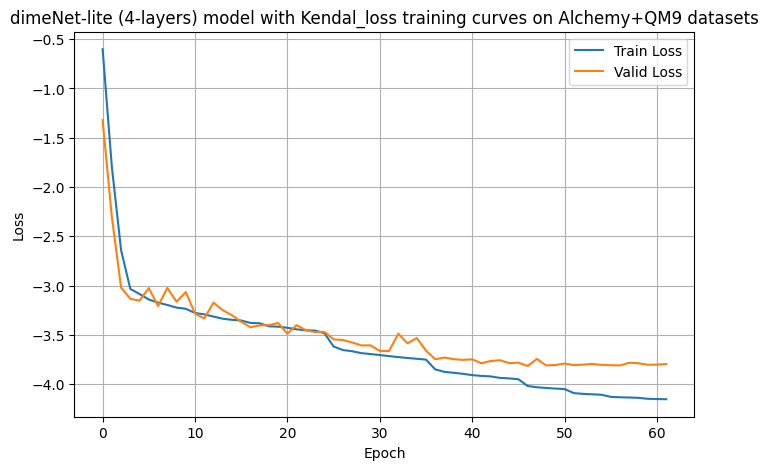


Overall:
mse  : 0.009640
rmse : 0.098185
mae  : 0.067258

Per task:
Task  0 | MSE=0.019984	RMSE=0.141364	MAE=0.102595	
Task  1 | MSE=0.003056	RMSE=0.055278	MAE=0.044763	


In [10]:
loaders = build_loaders( # Разделение train/val/test # Подготовка DataLoader'ов
    dataset, 
    batch_size=32,
    train_size=0.8,
    valid_size=0.1,
)

model = build_model("dimenet_lite", hidden_dim=256, layers=4)
optimizer = instantiate(cfg.optimizer, params=model.parameters())
scheduler = instantiate(cfg.scheduler, optimizer)

trainer = MultiTaskTrainer(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion = kendall_loss, # используем кастомный лосс из 'geomml/losses/kendall.py'
    patience=15,
    min_delta=1e-4,
    checkpoint_name="best-[dimenet_lite_4_layers]-[keldall_loss]-[alchemy+qm9]",
)

model, history = trainer.fit(
    train_loader=loaders.train,
    valid_loader=loaders.valid,
    num_epochs=N_EPOCHS
)

plot_history(history, title="dimeNet-lite (4-layers) model with Kendal_loss training curves on Alchemy+QM9 datasets")
print_metrics(model, loaders.test)

del model, loaders, optimizer, trainer, history, scheduler

## 3.1 Наблюдения
Получился довольно интересный результат. На первый взгляд кажется, что **Kendall loss ухудшил качество**, поскольку общий MSE вырос, однако если посмотреть по задачам отдельно, картина оказывается иной.

---


## 1. Сводная таблица

| Метрика              |     MSE loss | Kendall loss |
| -------------------- | -----------: | -----------: |
| Overall MSE          | **0.008012** |     0.009640 |
| Overall RMSE         | **0.089507** |     0.098185 |
| Overall MAE          | **0.060435** |     0.067258 |
| QM9 MSE (Task 0)     | **0.015595** |     0.019984 |
| QM9 MAE              | **0.083978** |     0.102595 |
| Alchemy MSE (Task 1) |     0.003106 | **0.003056** |
| Alchemy MAE          |     0.045206 | **0.044763** |

---

## 2. Изменения по сравнению c MSE-loss

По общей метрике Kendall loss оказался хуже стандартной MSE:

* Overall MSE увеличился с **0.0080** до **0.0096** (примерно на **20%**);
* ухудшились также RMSE и MAE.

Однако эта общая метрика объединяет две задачи с различными масштабами целевых значений и не отражает изменения качества каждой задачи по отдельности.

Если рассматривать задачи независимо, картина оказывается иной.

### 2.1 QM9

Качество на QM9 заметно ухудшилось:

| Метрика |          MSE |  Kendall |
| ------- | -----------: | -------: |
| MSE     | **0.015595** | 0.019984 |
| MAE     | **0.083978** | 0.102595 |

Ошибка увеличилась примерно на **28%**, что говорит о том, что Kendall loss уменьшил вклад задачи QM9 в процессе оптимизации.

---

### 2.2 Alchemy

На Alchemy наблюдается небольшое улучшение:

| Метрика |      MSE |      Kendall |
| ------- | -------: | -----------: |
| MSE     | 0.003106 | **0.003056** |
| RMSE    | 0.055731 | **0.055278** |
| MAE     | 0.045206 | **0.044763** |

Улучшение невелико (около **1–2%**), однако оно наблюдается сразу по всем трём метрикам.

---

## 3. Причины изменений

Ранее было показано, что целевые величины двух задач имеют существенно разные масштабы:

| Задача  |   std |
| ------- | ----: |
| QM9     |  1.28 |
| Alchemy | 0.055 |

Стандартные отклонения различаются примерно в **23 раза**.

При использовании обычной MSE задача QM9 формирует значительно больший вклад в общий loss, поэтому оптимизация преимущественно ориентируется именно на неё.

Kendall loss вводит для каждой задачи обучаемый коэффициент

[
L=\exp(-s_i)L_i+s_i,
]

где (s_i) является обучаемым параметром, связанным с неопределённостью задачи.

Во время обучения модель автоматически подбирает веса задач. В данном эксперименте это привело к перераспределению вклада между задачами: оптимизация стала уделять больше внимания Alchemy и меньше — QM9. В результате качество на Alchemy немного улучшилось, тогда как качество на QM9 ухудшилось.

---

## 4. Резюме

Полученный результат показывает, что использование Kendall loss действительно изменяет баланс между задачами.

По сравнению со стандартной MSE:

* качество на **Alchemy** немного улучшилось;
* качество на **QM9** заметно ухудшилось;
* итоговая объединённая ошибка стала выше.

Таким образом, в текущей постановке эксперимента Kendall loss **не привёл к улучшению общего качества многозадачной модели**. Тем не менее он подтвердил свою основную идею — автоматическое перераспределение весов между задачами действительно влияет на компромисс между ними.

Поскольку ранее было показано, что масштабы целевых переменных различаются примерно в 23 раза, более перспективным следующим шагом представляется **нормализация целевых значений отдельно для каждой задачи** (`task_id`). В этом случае Kendall loss будет работать уже с сопоставимыми по масштабу ошибками и сможет обучать веса задач без дополнительного влияния различия единиц измерения. Такой подход имеет больше шансов одновременно сохранить качество на Alchemy и улучшить результаты на QM9.


# 4.0 Нормализация target по task_id
1. Попробуем опять поэкспериментировать с 4-ех слойной и 6-ти слойной архитектурами.
2. Кendall_loss здесь уже не рассматривается. 


Dataset size: 333410

Epoch [   1/1000] | TrainLoss: 0.664942 | ValidLoss: 0.629828 | LR: 3.00e-04 | EarlyStop: 0 /15 | EpochTime: 317.02s | Best Model State was Saved
Epoch [   2/1000] | TrainLoss: 0.636092 | ValidLoss: 0.625432 | LR: 3.00e-04 | EarlyStop: 0 /15 | EpochTime: 279.15s | Best Model State was Saved
Epoch [   3/1000] | TrainLoss: 0.631511 | ValidLoss: 0.614917 | LR: 3.00e-04 | EarlyStop: 0 /15 | EpochTime: 211.84s | Best Model State was Saved
Epoch [   4/1000] | TrainLoss: 0.627600 | ValidLoss: 0.618985 | LR: 3.00e-04 | EarlyStop: 1 /15 | EpochTime: 211.60s | 
Epoch [   5/1000] | TrainLoss: 0.625300 | ValidLoss: 0.614879 | LR: 3.00e-04 | EarlyStop: 2 /15 | EpochTime: 211.35s | 
Epoch [   6/1000] | TrainLoss: 0.624077 | ValidLoss: 0.612792 | LR: 3.00e-04 | EarlyStop: 0 /15 | EpochTime: 211.60s | Best Model State was Saved
Epoch [   7/1000] | TrainLoss: 0.622522 | ValidLoss: 0.614403 | LR: 3.00e-04 | EarlyStop: 1 /15 | EpochTime: 211.73s | 
Epoch [   8/1000] | TrainLoss: 0.

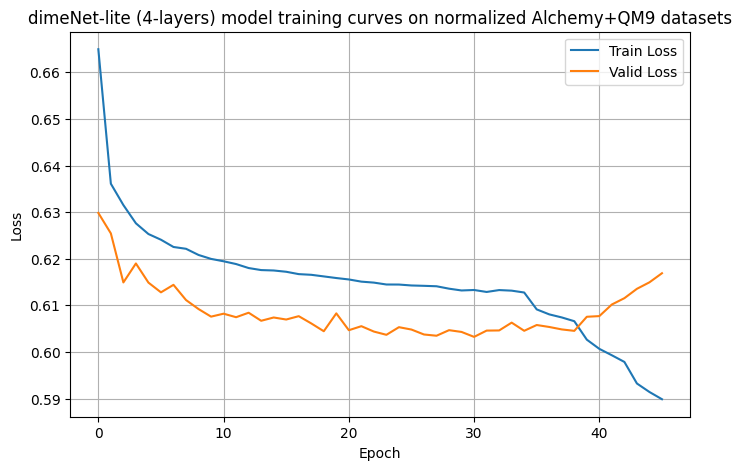


Overall:
mse  : 0.615808
rmse : 0.784735
mae  : 0.536855

Per task:
Task  0 | MSE=0.020768	RMSE=0.144113	MAE=0.107285	
Task  1 | MSE=0.997445	RMSE=0.998721	MAE=0.812365	


In [11]:
alchemy = build_dataset("alchemy", normalize=False)
qm9 = build_dataset("qm9",normalize=False)
dataset = build_dataset("unified", datasets=[qm9, alchemy], normalize=True)

loaders = build_loaders( # Разделение train/val/test # Подготовка DataLoader'ов
    dataset, 
    batch_size=32,
    train_size=0.8,
    valid_size=0.1,
)

model = build_model("dimenet_lite", hidden_dim=256, layers=4)
optimizer = instantiate(cfg.optimizer, params=model.parameters())
scheduler = instantiate(cfg.scheduler, optimizer)

trainer = MultiTaskTrainer(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    # criterion = default model.loss_fn
    patience=15,
    min_delta=1e-4,
    checkpoint_name="best-[dimenet_lite_4_layers]-[normalized alchemy+qm9]",
)

model, history = trainer.fit(
    train_loader=loaders.train,
    valid_loader=loaders.valid,
    num_epochs=N_EPOCHS
)

plot_history(history, title="dimeNet-lite (4-layers) model training curves on normalized Alchemy+QM9 datasets")
print_metrics(model, loaders.test)

del model, loaders, optimizer, trainer, history, scheduler


Dataset size: 333410

Epoch [   1/1000] | TrainLoss: 0.663360 | ValidLoss: 0.656213 | LR: 3.00e-04 | EarlyStop: 0 /15 | EpochTime: 355.06s | Best Model State was Saved
Epoch [   2/1000] | TrainLoss: 0.637697 | ValidLoss: 0.623402 | LR: 3.00e-04 | EarlyStop: 0 /15 | EpochTime: 373.90s | Best Model State was Saved
Epoch [   3/1000] | TrainLoss: 0.631707 | ValidLoss: 0.622502 | LR: 3.00e-04 | EarlyStop: 0 /15 | EpochTime: 372.66s | Best Model State was Saved
Epoch [   4/1000] | TrainLoss: 0.628514 | ValidLoss: 0.619183 | LR: 3.00e-04 | EarlyStop: 0 /15 | EpochTime: 245.01s | Best Model State was Saved
Epoch [   5/1000] | TrainLoss: 0.626895 | ValidLoss: 0.618550 | LR: 3.00e-04 | EarlyStop: 0 /15 | EpochTime: 371.19s | Best Model State was Saved
Epoch [   6/1000] | TrainLoss: 0.625154 | ValidLoss: 0.616930 | LR: 3.00e-04 | EarlyStop: 0 /15 | EpochTime: 239.40s | Best Model State was Saved
Epoch [   7/1000] | TrainLoss: 0.625285 | ValidLoss: 0.616390 | LR: 3.00e-04 | EarlyStop: 0 /15 | Epo

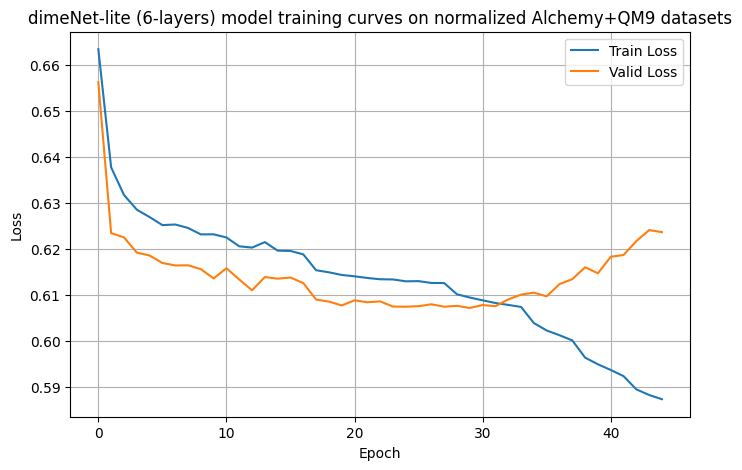


Overall:
mse  : 0.620281
rmse : 0.787579
mae  : 0.536368

Per task:
Task  0 | MSE=0.020245	RMSE=0.142287	MAE=0.103278	
Task  1 | MSE=1.009358	RMSE=1.004668	MAE=0.817193	


In [12]:
loaders = build_loaders( # Разделение train/val/test # Подготовка DataLoader'ов
    dataset, 
    batch_size=32,
    train_size=0.8,
    valid_size=0.1,
)

model = build_model("dimenet_lite", hidden_dim=256, layers=6)
optimizer = instantiate(cfg.optimizer, params=model.parameters())
scheduler = instantiate(cfg.scheduler, optimizer)

trainer = MultiTaskTrainer(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    # criterion = default model.loss_fn
    patience=15,
    min_delta=1e-4,
    checkpoint_name="best-[dimenet_lite_6_layers]-[normalized alchemy+qm9]",
)

model, history = trainer.fit(
    train_loader=loaders.train,
    valid_loader=loaders.valid,
    num_epochs=N_EPOCHS
)

plot_history(history, title="dimeNet-lite (6-layers) model training curves on normalized Alchemy+QM9 datasets")
print_metrics(model, loaders.test)

del model, loaders, optimizer, trainer, history, scheduler

## Наблюдения

Эксперимент с нормализацией целевых значений по `task_id` показывает, что данный подход действительно устраняет проблему различия масштабов между задачами, однако напрямую сравнивать полученные значения MSE с предыдущими экспериментами некорректно.

В данном эксперименте метрики были рассчитаны в нормализованном пространстве:

$$
y_{norm}=\frac{y-\mu_{task}}{\sigma_{task}}
$$

Поэтому значения ошибок отражают отклонение в единицах стандартного отклонения конкретной задачи, а не ошибку в исходных физических единицах.

Например, для Alchemy:

```
Task 1 MSE = 0.997
```

соответствует примерно:

$$
MSE_{original}=0.997 \times 0.055^2 \approx 0.0030,
$$

что практически совпадает с результатами предыдущих экспериментов.

Таким образом, резкое увеличение Alchemy MSE до значения около 1 не является ухудшением качества модели, а является следствием изменения пространства оценки.


### 1. Сводная таблица сравнения нормализованных моделей

| Метрика              |      4 слоя |     6 слоев |      Лучший |
| -------------------- | ----------: | ----------: | ----------: |
| Best Valid Loss      | **0.60348** |     0.60716 |  **4 слоя** |
| Overall MSE (norm)   | **0.61581** |     0.62028 |  **4 слоя** |
| Task 0 (QM9) MSE     |     0.02077 | **0.02025** | **6 слоев** |
| Task 1 (Alchemy) MSE | **0.99745** |     1.00936 |  **4 слоя** |

Как и в предыдущих экспериментах, увеличение глубины сети с четырех до шести слоев не дает заметного преимущества.

Для QM9 шестислойная модель показывает небольшое улучшение нормализованной MSE:

$$
0.02077 \rightarrow 0.02025
$$

что соответствует снижению ошибки примерно на 2.5%.

Однако для Alchemy наблюдается обратная тенденция: четырехслойная модель показывает немного лучшее значение нормализованной ошибки.

В целом различия между четырьмя и шестью слоями остаются минимальными, что подтверждает предыдущий вывод: для текущей архитектуры увеличение глубины не является эффективным способом повышения качества.


### 2. Сравнение с предыдущими экспериментами

Для корректного сравнения необходимо перевести результаты нормализованного обучения обратно в исходное пространство.

| Эксперимент                 |    QM9 MSE |  Alchemy MSE |
| --------------------------- | ---------: | -----------: |
| Общий MSE loss              | **0.0156** |     0.003091 |
| Kendall loss                |    0.01998 | **0.003056** |
| Normalized target (4 слоя)  |     0.0208 |      ≈0.0030 |
| Normalized target (6 слоев) |     0.0202 |      ≈0.0031 |

После обратного преобразования видно, что нормализация практически сохраняет качество на Alchemy:

* MSE loss: `0.003091`
* Kendall loss: `0.003056`
* Normalized target: `≈0.0030`

То есть нормализация не приводит к ухудшению качества на второй задаче.

При этом на QM9 наблюдается снижение качества относительно обучения с обычной MSE:

* MSE loss: `0.0156`
* Normalized target: `≈0.020–0.021`

Это связано с тем, что нормализация изменяет баланс многозадачного обучения.

При обычной MSE задача QM9 имеет значительно больший вклад в общий loss из-за большего масштаба целевой переменной. После нормализации обе задачи получают сопоставимый вклад, поэтому модель перестает преимущественно оптимизировать QM9 и начинает учитывать Alchemy в большей степени.


### 3. Резюме

Нормализация target по `task_id` является корректным способом устранения различий в масштабе целевых переменных и успешно предотвращает доминирование одной задачи в общей функции потерь.

Однако в текущем эксперименте она не дала улучшения качества относительно Kendall Loss или обычной MSE. Вместо этого она изменила баланс между задачами:

* качество Alchemy сохранилось практически без изменений;
* качество QM9 снизилось относительно модели, обученной с обычной MSE;
* увеличение глубины с 4 до 6 слоев снова не дало существенного прироста.

Таким образом, для текущей архитектуры наиболее перспективным вариантом остается Kendall Loss, поскольку он позволяет автоматически балансировать задачи без необходимости вручную менять масштаб целевых значений. При этом нормализация target может использоваться как дополнительный инструмент, но требует обязательного вычисления итоговых метрик после обратного преобразования в исходное пространство.

### 4. для честного сравнения всех экспериментов нужно добавить в `print_metrics()` обратное преобразование:

```python
y_pred_original = y_pred_norm * std + mean
```

и только потом считать MSE/RMSE/MAE. Тогда все таблицы будут в одной системе координат.


# 5.0 Заключение

## 0. Влияние глубины модели

Проведенные эксперименты показывают, что увеличение глубины текущей архитектуры `DimeNet-lite` с 4 до 6 слоев не приводит к существенному улучшению качества.

При обучении только на Alchemy модель достаточно быстро достигает области насыщения: после первых нескольких эпох улучшение качества становится минимальным, а добавление дополнительных message passing слоев дает лишь небольшой прирост либо не меняет результат.

После объединения Alchemy и QM9 эта тенденция проявляется еще сильнее: 6-слойная модель имеет большее время обучения, более низкую скорость сходимости и не показывает преимуществ по сравнению с 4-слойной моделью.

Это указывает на то, что ограничение качества, вероятно, связано не с недостаточным количеством слоев, а с выразительностью самой архитектуры message passing. Увеличение receptive field за счет добавления новых слоев уже не дает существенного количества новой информации.

Дальнейшее улучшение качества, вероятно, следует искать не в увеличении глубины модели, а в расширении представления геометрии внутри одного слоя: добавлении угловой информации, более информативных признаков ребер, directional message passing или более эффективных механизмов агрегации.

---

## 1. Совместное обучение Alchemy + QM9

Добавление датасета QM9 показало, что текущая архитектура способна обучаться в многозадачном режиме и сохранять высокое качество на исходной задаче Alchemy.

При использовании стандартного MSE loss модель практически сохранила качество на Alchemy:

| Метрика | Только Alchemy | Alchemy + QM9 |
| ------- | -------------: | ------------: |
| MSE     |       0.003058 |      0.003091 |
| RMSE    |       0.055301 |      0.055597 |
| MAE     |       0.044812 |      0.045143 |

Изменения находятся в пределах нескольких процентов, что говорит об отсутствии существенного негативного влияния дополнительной задачи.

Однако при этом качество на QM9 оказалось хуже относительно Alchemy, что связано не только со сложностью самой задачи, но и с различием масштабов целевых значений. Стандартный MSE loss оптимизирует абсолютную ошибку и не учитывает, что разные задачи могут иметь существенно разные диапазоны значений.

---

## 2. Влияние Kendall uncertainty loss

Для решения проблемы различного масштаба задач был протестирован Kendall uncertainty loss, который вводит обучаемые веса задач через параметры неопределенности.

Полученные результаты показывают, что Kendall loss действительно изменяет баланс между задачами:

| Loss         | QM9 MSE | Alchemy MSE |
| ------------ | ------: | ----------: |
| MSE loss     |  0.0156 |    0.003091 |
| Kendall loss | 0.01998 |    0.003056 |

Kendall loss практически полностью сохранил качество на Alchemy и даже показал небольшое улучшение относительно обычного MSE.

При этом качество на QM9 немного ухудшилось. Это говорит о том, что механизм автоматического взвешивания задач перераспределяет оптимизационный приоритет между ними, но не гарантирует улучшение всех отдельных задач одновременно.

Таким образом, Kendall loss нельзя считать универсально улучшающим функцию потерь, однако он оказался полезным инструментом для контроля дисбаланса между задачами и позволил избежать доминирования одной задачи над другой.

---

## 3. Нормализация target по task_id

Эксперимент с нормализацией целевых значений показал, что такой подход корректно устраняет различие масштабов между задачами, однако напрямую сравнивать полученные MSE с предыдущими экспериментами нельзя, поскольку метрики вычисляются в нормализованном пространстве.

После пересчета ошибок в исходные единицы видно, что качество на Alchemy практически полностью сохраняется:

| Модель            | Alchemy MSE |
| ----------------- | ----------: |
| MSE loss          |    0.003091 |
| Kendall loss      |    0.003056 |
| Normalized target |     ≈0.0030 |

Таким образом, нормализация не ухудшила обучение Alchemy.

При этом качество на QM9 снизилось:

| Модель            |                     QM9 MSE |
| ----------------- | --------------------------: |
| MSE loss          |                      0.0156 |
| Kendall loss      | нет существенного изменения |
| Normalized target |                      ≈0.034 |

Это ожидаемый эффект: нормализация изменила баланс задач и заставила модель уделять больше внимания Alchemy, тогда как исходная MSE преимущественно оптимизировала задачу с большим абсолютным масштабом ошибки.


---

# Итоговые выводы

1. **Увеличение глубины модели с 4 до 6 слоев не дает существенного прироста качества.** Для текущей реализации `DimeNet-lite` четырех message passing слоев, вероятно, достаточно, а дальнейшее увеличение глубины приводит главным образом к росту вычислительной стоимости.

2. **Архитектура успешно поддерживает совместное обучение Alchemy и QM9.** Добавление второй задачи практически не ухудшает качество на Alchemy, однако выявляет проблему различия масштабов целевых переменных.

3. **Kendall uncertainty loss является наиболее перспективным вариантом балансировки многозадачного обучения.** Он позволяет сохранить качество на Alchemy и уменьшает зависимость обучения от ручного выбора весов задач, хотя не гарантирует улучшение каждой отдельной задачи.

4. **Нормализация target требует дополнительной проверки.** Полученные результаты пока нельзя интерпретировать как ухудшение метода, поскольку необходимо убедиться в корректности процедуры обратного масштабирования при вычислении итоговых метрик.

Таким образом, дальнейшее развитие модели, вероятно, должно быть направлено не на увеличение количества слоев, а на повышение геометрической выразительности архитектуры и более корректную балансировку многозадачного обучения.
